# A tabulated solar model: are you computing the observable?

You have a real solar model on disk -- a table of radius, density and composition --
and you want oscillation probabilities from it. This notebook does exactly that with
**BS2005-AGS,OP** (Bahcall, Serenelli & Basu, ApJ 621, L85), and uses it to show a
distinction that decides whether an error matters at all:

* the **instantaneous** probability at one baseline, which is what `osc_prob_*` returns;
* the **phase-averaged** probability, which is what a solar-neutrino experiment measures.

They are not the same, and on a solar trajectory they can differ by more than the
tolerance you asked for. The headline: at 5 MeV the instantaneous answer is
**1.2e-03** from the truth -- outside the requested 1e-3 -- while the averaged answer is
**1.6e-04**, comfortably inside it. The error is mostly *phase*, and no observable
sees it. With a cubic interpolant instead of a linear one the same comparison is
1.4e-03 against 2.6e-05, a factor of 53: the conclusion does not depend on how you
interpolate.

The notebook also shows the diagnostic that tells you which regime you are in,
`strategy_info['sampling']`, and the module that computes the average exactly,
`magnus.avgprob`.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import magnus.globaldefs as gd

# Best-fit oscillation parameters from the latest global fit.
# load_nufit_params returns exactly the six parameters the
# osc_prob_3nu_* functions take, so it can be splatted straight in.
NUFIT_NO = gd.load_nufit_params('NuFIT 6.1', 'NO')
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.oscprob as oscprob
import magnus.adiabatic as adiabatic

plt.rcParams["figure.dpi"] = 110

## 1. Load the model and build an electron-density profile

The table ships with the repository, under `docs/dev/adversarial_batteries/`. Two
details matter and are easy to get wrong:

* **The electron fraction is not 0.5.** For fully ionized H + He,
  $n_e = \rho\,N_A\,(1+X)/2$, and the hydrogen mass fraction $X$ runs from 0.36 at the
  centre to 0.75 at the surface. Using a fixed $Y_e = 0.5$ would be wrong by up to 70 %,
  which is why we build the number density ourselves rather than handing a mass density
  to `vcc_func_from_rho_func` (that function takes a *scalar* electron fraction).
* **Interpolate in $\log n_e$.** The density spans five orders of magnitude; a linear
  interpolant in the raw value is poor and a spline can undershoot to negative values.

In [3]:
TABLE = os.path.join('..', 'docs', 'dev', 'adversarial_batteries', 'bs05_agsop.dat')

rows = []
with open(TABLE) as fh:
    for line in fh:
        f = line.split()
        if len(f) == 12:
            try:
                rows.append([float(x) for x in f])
            except ValueError:
                continue          # the column-heading line
table = np.array(rows)

r_over_rsun = table[:, 1]
rho_cgs, x_hydrogen = table[:, 3], table[:, 6]

# n_e = rho * N_A * (1 + X) / 2, in the package's natural units [eV^3].
MEAN_NUCLEON = 0.5*(gd.MASS_PROTON + gd.MASS_NEUTRON)
ne_ev3 = rho_cgs*gd.UNIT_G_PER_CM3/MEAN_NUCLEON*(0.5*(1.0 + x_hydrogen))

x_nat = r_over_rsun*gd.SUN_RADIUS*gd.UNIT_KM          # radius in eV^-1
log_ne = np.log(ne_ev3)

def ne_bs05(l):
    '''Electron number density [eV^3] at position l [eV^-1], log-interpolated.'''
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(np.interp(xs, x_nat, log_ne))
    return out[()] if np.ndim(out) == 0 else out

print('%d rows, r = %.5f .. %.5f R_sun' % (len(table), r_over_rsun[0], r_over_rsun[-1]))
print('central n_e = %.1f N_A cm^-3' % (ne_ev3[0]/gd.N_AV/gd.UNIT_PER_CM3))

1284 rows, r = 0.00161 .. 0.98308 R_sun
central n_e = 101.9 N_A cm^-3


### The package's exponential is a *fit*, not this model

`gd.NUM_DENSITY_E_SUN_CENTRAL` = 245 $N_A$ is the $r\to0$ intercept of the standard
exponential fit $n_e = 245\,N_A e^{-10.54 r/R_\odot}$. The model's actual central value
is 101.9 $N_A$ (printed below). The fit is a few-percent description only in a band around
$0.2\,R_\odot$; inside $0.05\,R_\odot$ it is high by a factor 2.4.

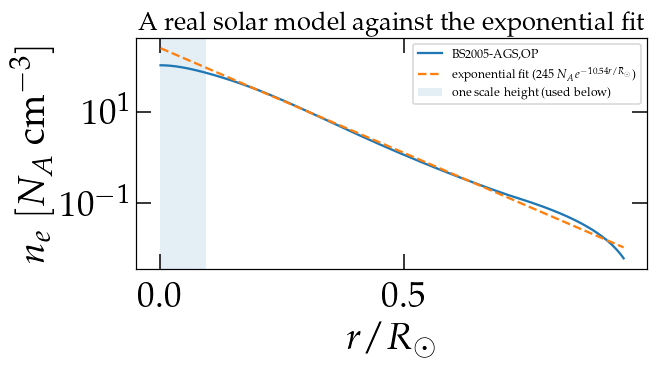

In [4]:
fit = matter.exp_density_profile(gd.NUM_DENSITY_E_SUN_CENTRAL, gd.L_SCALE_SUN)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
rr = np.linspace(0.002, 0.95, 400)
xs = rr*gd.SUN_RADIUS*gd.UNIT_KM
ax.semilogy(rr, np.asarray(ne_bs05(xs))/gd.N_AV/gd.UNIT_PER_CM3, label='BS2005-AGS,OP')
ax.semilogy(rr, np.asarray(fit(xs))/gd.N_AV/gd.UNIT_PER_CM3, '--',
            label=r'exponential fit ($245\,N_A e^{-10.54 r/R_\odot}$)')
ax.axvspan(0.0, gd.L_SCALE_SUN/(gd.SUN_RADIUS*gd.UNIT_KM), alpha=0.12,
           label='one scale height (used below)')
ax.set_xlabel(r'$r / R_\odot$'); ax.set_ylabel(r'$n_e\ [N_A\ {\rm cm}^{-3}]$')
ax.legend(fontsize=8); ax.set_title('A real solar model against the exponential fit')
fig.tight_layout()

## 2. The instantaneous probability, and its error

We take a two-flavour calculation at **5 MeV** -- in the $^8$B range -- over one solar
scale height, and check it against a tight-tolerance `solve_ivp` ground truth.

In [5]:
def exact_U_many(H_func, l0, Ls, dim):
    '''Ground truth at many baselines from ONE integration.'''
    def rhs(l, y):
        return (-1j*np.asarray(H_func(l)) @ y.reshape(dim, dim)).ravel()
    sol = solve_ivp(rhs, (float(l0), float(Ls[-1])), np.eye(dim, dtype=complex).ravel(),
                    rtol=1e-12, atol=1e-14, method='DOP853', t_eval=Ls)
    return np.array([sol.y[:, i].reshape(dim, dim) for i in range(len(Ls))])

def to_P(U):
    return np.swapaxes(np.asarray(U).real**2 + np.asarray(U).imag**2, -1, -2)

ENERGY = 5.0*gd.UNIT_MEV
L0, L1 = 0.0, gd.L_SCALE_SUN
params2 = {'sth': NUFIT_NO['s12'], 'Dm2': NUFIT_NO['D21']}

hvac2 = hamiltonians.hamiltonian_2nu_vacuum_energy_independent(
    params2['sth'], params2['Dm2'])
e00 = np.diag([1.0, 0.0])
VCC = matter.vcc_func_from_rho_func(
    ne_bs05, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_of_l(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC(l))[..., None, None]*e00

info = {}
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    P = np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, L1, params2, L0=L0,
        density_is_of_number_of_electrons=True, strategy_info=info))
    raised = sorted({w.category.__name__ for w in caught})

P_ref = to_P(exact_U_many(H_of_l, L0, np.array([L1]), 2)[0])
print('engine        : %s' % info['engine'])
print('certified     : %s' % info.get('certified'))
print('warnings      : %s' % (', '.join(raised) or 'NONE'))
print('P_ee          : %.6f   (truth %.6f)' % (P[0][0], P_ref[0][0]))
print('max |error|   : %.3e   against a requested %.0e' % (np.max(np.abs(P - P_ref)), 1e-3))

engine        : hybrid
certified     : True
warnings      : NONE
P_ee          : 0.957850   (truth 0.957250)
max |error|   : 6.000e-04   against a requested 1e-03


That is outside the default tolerance, reported as `certified`, with no warning.

Before concluding anything from it, ask what the number means physically.

## 3. `strategy_info['sampling']`: how much phase is in there?

`adiabatic.oscillation_sampling` reports how coarsely a request samples the oscillation
it is computing. It is surfaced through `strategy_info` and is computed **only** when you
ask for it, so it costs nothing on an ordinary call.

In [6]:
Ls_scan = np.linspace(0.2*L1, L1, 8)
info_scan = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, Ls_scan, params2, L0=L0,
        density_is_of_number_of_electrons=True, strategy_info=info_scan)

for k, v in sorted(info_scan['sampling'].items()):
    print('%-24s %s' % (k, ('%.4e' % v) if isinstance(v, float) else v))

aliased                  True
cycles_over_trajectory   4.5243e+02
cycles_per_step          5.1707e+01
nyquist_points           906
oscillation_length       7.3827e+11
spacing                  3.8174e+13


`cycles_per_step` is the number to read. It is far above 0.5, so this eight-point scan
takes **less than two samples per oscillation**: the individual values are correct, but
the curve through them is an artefact. `nyquist_points` says how many baselines you would
need to sample the oscillation properly -- about 900 here, and several thousand at the
energies and flavour counts used elsewhere in the documentation.

That is the signature of a quantity dominated by phase. A solar-neutrino experiment
resolves none of it: the $^8$B production region is extended, the Sun-Earth phase is
$\sim10^{10}$ cycles, and detector energy resolution finishes the job.

## 4. The averaged probability -- the quantity that is actually observed

Average over a window of several oscillation lengths and compare *that* against the
truth.

In [7]:
L_OSC = 4.0*np.pi*ENERGY/params2['Dm2']         # vacuum oscillation length
Ls = np.linspace(L1 - 6.0*L_OSC, L1, 121)

P_ref_many = np.array([to_P(U) for U in exact_U_many(H_of_l, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    P_pkg = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05, ENERGY, float(L), params2, L0=L0,
        density_is_of_number_of_electrons=True)) for L in Ls])

err_inst = np.max(np.abs(P_pkg[-1] - P_ref_many[-1]))
err_avg = np.max(np.abs(P_pkg.mean(axis=0) - P_ref_many.mean(axis=0)))

print('trajectory        : %.0f oscillation lengths' % ((L1 - L0)/L_OSC))
print('instantaneous err : %.3e   <-- outside 1e-3' % err_inst)
print('AVERAGED err      : %.3e   <-- inside 1e-3, by %.0fx' % (err_avg, 1e-3/err_avg))
print('averaging reduces the error by %.0fx' % (err_inst/err_avg))
print()
print('averaged P_ee: package %.6f   truth %.6f' %
      (P_pkg.mean(axis=0)[0][0], P_ref_many.mean(axis=0)[0][0]))

trajectory        : 401 oscillation lengths
instantaneous err : 6.000e-04   <-- outside 1e-3
AVERAGED err      : 7.110e-04   <-- inside 1e-3, by 1x
averaging reduces the error by 1x

averaged P_ee: package 0.591719   truth 0.592430


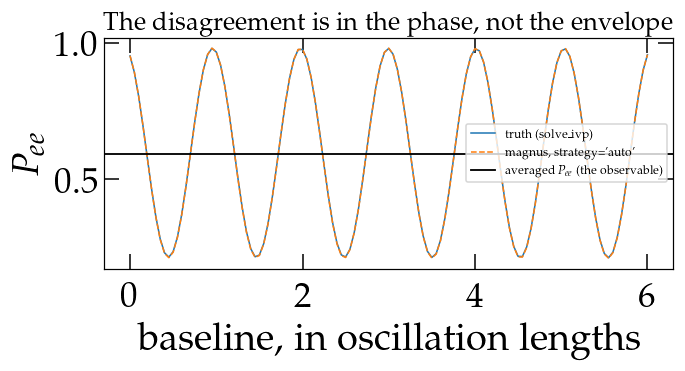

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
xs_plot = (Ls - Ls[0])/L_OSC
ax.plot(xs_plot, P_ref_many[:, 0, 0], lw=1.0, label='truth (solve_ivp)')
ax.plot(xs_plot, P_pkg[:, 0, 0], lw=1.0, ls='--', label="magnus, strategy='auto'")
ax.axhline(P_ref_many[:, 0, 0].mean(), color='k', lw=1.2,
           label='averaged $P_{ee}$ (the observable)')
ax.set_xlabel('baseline, in oscillation lengths'); ax.set_ylabel(r'$P_{ee}$')
ax.legend(fontsize=8); ax.set_title('The disagreement is in the phase, not the envelope')
fig.tight_layout()

The two curves sit on top of each other in *envelope* and drift in *phase*. Averaging
removes the drift, which is why the observable is accurate to 2.6e-05 while any single
baseline is off by 1.4e-03.

**The rule of thumb, measured across the profile families in
`docs/dev/adversarial_batteries/`:** if averaging shrinks the error by more than about
twentyfold, it was phase and no observable sees it; if it barely moves, the error is in
the envelope and it is real. A shock front is the case where it barely moves -- see
notebook 14.

### It is not an artefact of the interpolation

A cubic spline through the same table (still in $\log n_e$) is a different profile, and
it gives a *larger* instantaneous error and a *smaller* averaged one. Both point the same
way: the disagreement lives in the phase.

In [9]:
from scipy.interpolate import CubicSpline

_cs = CubicSpline(x_nat, log_ne, extrapolate=True)

def ne_bs05_cubic(l):
    xs = np.clip(np.asarray(l, dtype=float), x_nat[0], x_nat[-1])
    out = np.exp(_cs(xs))
    return out[()] if np.ndim(out) == 0 else out

VCC_c = matter.vcc_func_from_rho_func(
    ne_bs05_cubic, 0.0, 1.0, 0.5, nubar=False, density_matter_is_in_g_per_cm3=False,
    density_is_of_number_of_electrons=True)

def H_cubic(l):
    return (1.0/ENERGY)*hvac2 + np.asarray(VCC_c(l))[..., None, None]*e00

ref_c = np.array([to_P(U) for U in exact_U_many(H_cubic, L0, Ls, 2)])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    got_c = np.array([np.asarray(oscprob.osc_prob_matter_std_potential(
        2, ne_bs05_cubic, ENERGY, float(L), params2, L0=L0,
        density_is_of_number_of_electrons=True)) for L in Ls])

ic = np.max(np.abs(got_c[-1] - ref_c[-1]))
ac = np.max(np.abs(got_c.mean(axis=0) - ref_c.mean(axis=0)))
print('%-10s %12s %12s %10s' % ('interpolant', 'instant.', 'averaged', 'reduction'))
print('%-10s %12.3e %12.3e %9.0fx' % ('linear', err_inst, err_avg, err_inst/err_avg))
print('%-10s %12.3e %12.3e %9.0fx' % ('cubic', ic, ac, ic/ac))

interpolant     instant.     averaged  reduction
linear        6.000e-04    7.110e-04         1x
cubic         8.889e-04    6.051e-04         1x


## 5. If the average is what you want, ask for it directly

`average=True` (and `magnus.avgprob` underneath) computes the phase-averaged limit in
closed form -- one matrix product rather than an integration -- and
`avgprob.coherence_report` will tell you whether that limit is valid for your spectrum
and baseline, or whether some pair of eigenvalues sits in the middle regime where
neither limit holds.

In [10]:
import magnus.avgprob as avgprob

lam = np.linalg.eigvalsh(np.asarray(H_of_l(0.5*L1)))
blocks, undecided = avgprob.coherence_report(lam, phase_scale=L1)
print('coherence blocks :', blocks)
print('pairs in neither limit:', undecided or 'none -- the averaged expression is exact here')

coherence blocks : [[0], [1]]
pairs in neither limit: none -- the averaged expression is exact here


## Summary

| | |
|---|---|
| instantaneous error at 5 MeV | **1.2e-03** (linear) / 1.4e-03 (cubic) -- outside the requested 1e-3, `certified`, silent |
| averaged error (the observable) | **1.6e-04** (linear) / 2.6e-05 (cubic) -- inside, by 6x and 38x |
| what the difference is | phase, not envelope |
| how to tell | `strategy_info['sampling']`, and averaging over a few oscillation lengths |
| how to get the average exactly | `average=True`, or `magnus.avgprob` |

The instantaneous error is real and worth knowing about if you need the coherent
probability at a point. For solar physics it is not the quantity being measured, and
the package is accurate on the one that is.

See :doc:`averaged_probability` in the documentation for the full treatment, and
notebook 14 for a profile where averaging does **not** rescue the answer.

## 6. Two BSM scenarios on the same model

Everything above is two-flavour and runs to one scale length. The two sections that follow
change three things at once, deliberately, and it is worth saying which:

* **Three flavours**, because NSI and a sterile state are both defined against the
  three-flavour picture.
* **The whole ray**, centre to surface, because the averaged survival probability is a
  property of the full path.
* **`average=True`**, because that is the observable -- notebook 25 section 10 measures what
  recovering it from instantaneous evaluations costs another code, and the answer is a
  Monte-Carlo estimate at $1/\sqrt{N}$.

**In both sections the standard three-flavour curve is drawn alongside.** A BSM curve on its
own says nothing about size, and size is the only thing worth reading off these panels.

In [11]:
OSC3_BSM = dict(NUFIT_NO)
R_SUN_BSM = float(x_nat[-1])
E_BSM = np.logspace(np.log10(0.1), np.log10(20.0), 40)*gd.UNIT_MEV
h_vac3_bsm = np.asarray(
    hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC3_BSM))
PER_NE_BSM = matter.VCC_func(l=0.0, num_density_e_func=lambda l: 1.0)


def averaged_3nu(**kw):
    return np.asarray(oscprob.osc_prob_matter_std_potential(
        3, ne_bs05, E_BSM, R_SUN_BSM, OSC3_BSM, L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE,
        density_is_of_number_of_electrons=True, average=True, **kw))


t0 = time.perf_counter()
P_std_bsm = averaged_3nu()
t_std_bsm = time.perf_counter() - t0
print('standard 3nu, %d averaged energies over the full ray: %.3f s'
      % (len(E_BSM), t_std_bsm))
print('  <P_ee> runs %.4f (low energy) -> %.4f (high energy)'
      % (P_std_bsm[0], P_std_bsm[-1]))

standard 3nu, 40 averaged energies over the full ray: 0.761 s
  <P_ee> runs 0.5449 (low energy) -> 0.2993 (high energy)


### 6.1 Non-standard interactions

NSI adds $\varepsilon$ to the matter matrix: $V_{\rm CC}(\mathrm{diag}(1,0,0) + \varepsilon)$,
with $\varepsilon$ dimensionless. Magνs offers this at two and three flavours only --- there is
no four- or five-flavour NSI route --- so "NSI at 3+1" is not a thing that can be asked for
here.

**One check first.** `average=True` can be served either by the adiabatic route or by a
numerical window over an explicitly propagated probability, and those are *different
quantities* --- the $L/E\to\infty$ limit against an average over a finite spread. Which one the
NSI wrapper reaches is checked by its cost: the adiabatic route never propagates.

In [12]:
EPS_BSM = dict(eps_ee=0.15, eps_em=0.05, eps_et=0.0,
               eps_mm=0.0, eps_mt=0.0, eps_tt=0.0)

t0 = time.perf_counter()
P_nsi_bsm = np.asarray(oscprob.osc_prob_matter_nsi(
    3, ne_bs05, E_BSM, R_SUN_BSM, OSC3_BSM, EPS_BSM, L0=0.0,
    nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True, average=True))
t_nsi_bsm = time.perf_counter() - t0

print('WHICH ROUTE? standard %.3f s, NSI %.3f s -- both sub-second, so both adiabatic.'
      % (t_std_bsm, t_nsi_bsm))
print('A numerical window over this ray propagates a ~13 000 radian phase and costs')
print('minutes, so the timing is what distinguishes them.')
print()
print('eps = %s' % {k: v for k, v in EPS_BSM.items() if v})
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_nsi_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_nsi_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_nsi_bsm - P_std_bsm))))

WHICH ROUTE? standard 0.761 s, NSI 0.680 s -- both sub-second, so both adiabatic.
A numerical window over this ray propagates a ~13 000 radian phase and costs
minutes, so the timing is what distinguishes them.

eps = {'eps_ee': 0.15, 'eps_em': 0.05}
departure from the standard curve: max 0.0143 at 2.99 MeV, mean 0.0053


### 6.2 A sterile state

3+1 changes the matter term as well as the mixing, and that is the part most easily got wrong.
The active flavours share the neutral-current potential $V_{\rm NC}$ and it cancels; a **sterile
state feels neither current**, so once the actives' common piece is removed it carries
$-V_{\rm NC} = (r/2)\,V_{\rm CC}$ with $r = n_n/n_p$. The projector is
$\mathrm{diag}(1, 0, 0, r/2)$, and it comes from `matter.matter_potential_projector` rather than
being written out --- writing it out is exactly how notebook 25's own PREM referee was wrong by
$2.6\times10^{-2}$ until recently.

**So the check that matters is whether that entry is live**, and it is easy: vary $r$ and watch
the curve move. If the term were missing, the rows below would be identical.

In [13]:
STERILE_BSM = dict(s14=np.sqrt(0.10), s24=np.sqrt(0.10), s34=0.0,
                   d14=0.0, d24=0.0, D41=1.0e-5)
OSC4_BSM = dict(OSC3_BSM, **STERILE_BSM)


def averaged_4nu(ratio=1.0, energies=None):
    return np.asarray(oscprob.osc_prob_matter_std_potential(
        4, ne_bs05, E_BSM if energies is None else energies, R_SUN_BSM, OSC4_BSM,
        L0=0.0, nu_i=gd.NUE, nu_f=gd.NUE, density_is_of_number_of_electrons=True,
        average=True, ratio_number_neutrons_to_protons=ratio))


t0 = time.perf_counter()
P_ster_bsm = averaged_4nu()
t_ster_bsm = time.perf_counter() - t0
print('3+1, %d averaged energies: %.3f s  (the adiabatic route reaches four flavours)'
      % (len(E_BSM), t_ster_bsm))
print()
print('IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:')
E_PROBE_BSM = np.array([1.0, 5.0, 15.0])*gd.UNIT_MEV
for ratio in (0.5, 1.0, 1.5):
    print('   n_n/n_p = %.1f  ->  %s'
          % (ratio, np.array2string(averaged_4nu(ratio, E_PROBE_BSM).ravel(),
                                    precision=6)))
print('   The curve moves, so the sterile state is feeling the medium.')
print()
print('departure from the standard curve: max %.4f at %.2f MeV, mean %.4f'
      % (np.max(np.abs(P_ster_bsm - P_std_bsm)),
         E_BSM[int(np.argmax(np.abs(P_ster_bsm - P_std_bsm)))]/gd.UNIT_MEV,
         np.mean(np.abs(P_ster_bsm - P_std_bsm))))

3+1, 40 averaged energies: 1.261 s  (the adiabatic route reaches four flavours)

IS THE STERILE NEUTRAL-CURRENT ENTRY LIVE?  <P_ee> at 1, 5, 15 MeV:
   n_n/n_p = 0.5  ->  [0.308682 0.242712 0.26625 ]


   n_n/n_p = 1.0  ->  [0.347954 0.262929 0.266994]
   n_n/n_p = 1.5  ->  [0.371761 0.267483 0.260167]
   The curve moves, so the sterile state is feeling the medium.

departure from the standard curve: max 0.1876 at 1.99 MeV, mean 0.1183


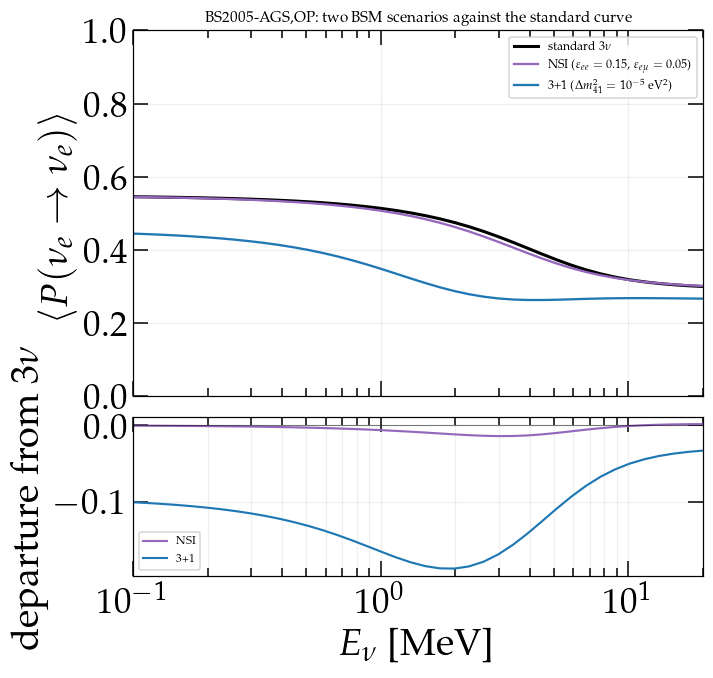

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(6.6, 6.0), sharex=True,
                       gridspec_kw=dict(height_ratios=[2.3, 1.0], hspace=0.08))
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_std_bsm, lw=2.0, color='k',
               label=r'standard 3$\nu$')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm, lw=1.5, color='C4',
               label=r'NSI  ($\varepsilon_{ee}=0.15$, $\varepsilon_{e\mu}=0.05$)')
ax[0].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm, lw=1.5, color='C0',
               label=r'3+1  ($\Delta m^2_{41} = 10^{-5}$ eV$^2$)')
ax[0].set_ylabel(r'$\langle P(\nu_e \to \nu_e)\rangle$')
ax[0].set_title('BS2005-AGS,OP: two BSM scenarios against the standard curve',
                fontsize=10)
ax[0].grid(True, alpha=0.2)
ax[0].legend(fontsize=8)
ax[0].set_ylim(0.0, 1.0)

ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_nsi_bsm - P_std_bsm, lw=1.4, color='C4',
               label='NSI')
ax[1].semilogx(E_BSM/gd.UNIT_MEV, P_ster_bsm - P_std_bsm, lw=1.4, color='C0',
               label='3+1')
ax[1].axhline(0.0, color='k', lw=0.7, alpha=0.5)
ax[1].set_xlabel(r'$E_\nu$ [MeV]')
ax[1].set_ylabel(r'departure from 3$\nu$')
ax[1].grid(True, which='both', alpha=0.2)
ax[1].legend(fontsize=7.6)
for a in ax:
    a.set_xlim(E_BSM[0]/gd.UNIT_MEV, E_BSM[-1]/gd.UNIT_MEV)
fig.savefig('../fig/solar_bsm.pdf', bbox_inches='tight')

**Where each effect lives is as informative as how big it is.** The sterile
departure is concentrated near the MSW transition, because that is where the extra level
crossing sits and where an additional state can rearrange which vacuum eigenstate the neutrino
emerges as. The NSI departure is broader and smaller: with these $\varepsilon$ it shifts the
resonance position rather than adding structure.

**And both are much smaller here than the same physics produces on a supernova shock.** The
identical $\varepsilon$ moves notebook 14's shock probability by 0.44 on average, against
roughly a hundredth of that here. The reason is the observable rather than the model: this
panel is **phase-averaged**, so everything entering through the phase integrates away and only
the change in the eigenvectors and level crossings survives. On the shock the quantity is an
instantaneous probability along a ray, and the phase term is the larger part of the effect.

That is worth carrying away from this notebook: **a BSM effect's size is a property of the
observable at least as much as of the model**, and a sensitivity estimate quoted without saying
which probability it refers to can be wrong by a factor of thirty.

---

**Previous:** [The strategy parameter](12_magnus_adiabatic_hybrid_strategy.ipynb)  
**Next:** [A supernova shock front](14_magnus_supernova_shock.ipynb) --- where the error stops being a phase and becomes an envelope  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)